In [53]:
!pip install pandas
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd

# Load dataset
df = pd.read_csv("placement.csv")

In [7]:
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [8]:
# Dataset shape
print("Shape:", df.shape)

# Column names
print("Columns:", df.columns)

# Info
df.info()

# Check missing values
df.isnull().sum()

Shape: (10000, 12)
Columns: Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  str    
 8   PlacementTraining          10000 non-null  str    

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [15]:
df = df.drop("StudentID", axis=1,errors='ignore')

In [16]:
df.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,NaN,NaN,61,79,NaN
1,8.9,0,3,2,90,4.0,NaN,NaN,78,82,1.0
2,7.3,1,2,2,82,4.8,NaN,NaN,79,80,NaN
3,7.5,1,1,2,85,4.4,NaN,NaN,81,80,1.0
4,8.3,1,2,2,86,4.5,NaN,NaN,74,88,1.0


In [12]:
df["ExtracurricularActivities"] = df["ExtracurricularActivities"].map({"Yes": 1, "No": 0})
df["PlacementTraining"] = df["PlacementTraining"].map({"Yes": 1, "No": 0})

In [13]:
df["PlacementStatus"] = df["PlacementStatus"].map({"Placed": 1, "Not Placed": 0})

In [17]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CGPA                       10000 non-null  float64
 1   Internships                10000 non-null  int64  
 2   Projects                   10000 non-null  int64  
 3   Workshops/Certifications   10000 non-null  int64  
 4   AptitudeTestScore          10000 non-null  int64  
 5   SoftSkillsRating           10000 non-null  float64
 6   ExtracurricularActivities  0 non-null      float64
 7   PlacementTraining          0 non-null      float64
 8   SSC_Marks                  10000 non-null  int64  
 9   HSC_Marks                  10000 non-null  int64  
 10  PlacementStatus            4197 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 859.5 KB


In [18]:
X = df.drop("PlacementStatus", axis=1)
y = df["PlacementStatus"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [34]:
df["PlacementStatus"].unique()

<ArrowStringArray>
[nan, '1.0']
Length: 2, dtype: str

In [35]:
df["PlacementStatus"].value_counts()


PlacementStatus
1.0    4197
Name: count, dtype: int64

In [39]:
df["PlacementStatus"] = df["PlacementStatus"].map({
    "Placed": 1,
    "Not Placed": 0
})

In [38]:
import pandas as pd

df = pd.read_csv("placement.csv")
df["PlacementStatus"].value_counts()
df["PlacementStatus"] = df["PlacementStatus"].map({
    "Placed": 1,
    "NotPlaced": 0
})
df["PlacementStatus"].value_counts()

PlacementStatus
0    5803
1    4197
Name: count, dtype: int64

In [40]:
import pandas as pd

df = pd.read_csv("placement.csv")

# Convert target
df["PlacementStatus"] = df["PlacementStatus"].map({
    "Placed": 1,
    "NotPlaced": 0
})

# Convert categorical columns FIRST
df["ExtracurricularActivities"] = df["ExtracurricularActivities"].map({
    "Yes": 1,
    "No": 0
})

df["PlacementTraining"] = df["PlacementTraining"].map({
    "Yes": 1,
    "No": 0
})

# NOW create X and y
X = df.drop(["PlacementStatus", "StudentID"], axis=1)
y = df["PlacementStatus"]

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# Evaluation
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, lr.predict(X_test)))
print("Decision Tree:", accuracy_score(y_test, dt.predict(X_test)))
print("Random Forest:", accuracy_score(y_test, rf.predict(X_test)))

Logistic Regression: 0.7945
Decision Tree: 0.722
Random Forest: 0.7835


In [52]:
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


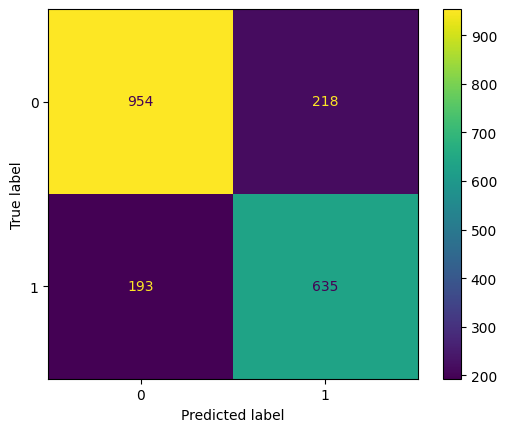

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, lr.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr.predict(X_test)))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1172
           1       0.74      0.77      0.76       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.79      0.79      2000



<Axes: >

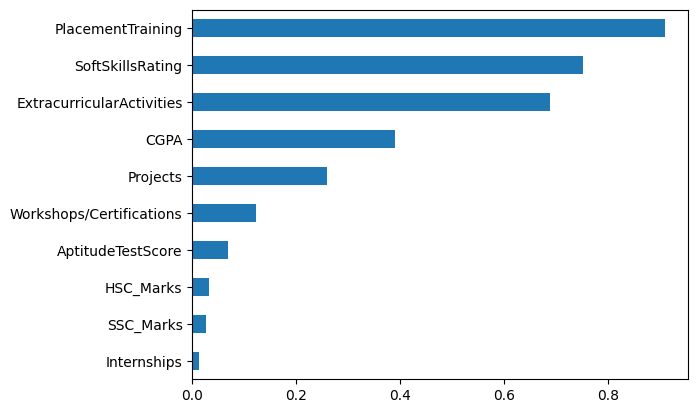

In [54]:
import pandas as pd

feature_importance = pd.Series(lr.coef_[0], index=X.columns)
feature_importance.sort_values().plot(kind='barh')

In [55]:
def predict_placement(input_data):
    input_df = pd.DataFrame([input_data], columns=X.columns)
    
    prediction = lr.predict(input_df)
    
    if prediction[0] == 1:
        return "Placed ✅"
    else:
        return "Not Placed ❌"

In [56]:
print(X.columns)

Index(['CGPA', 'Internships', 'Projects', 'Workshops/Certifications',
       'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities',
       'PlacementTraining', 'SSC_Marks', 'HSC_Marks'],
      dtype='str')


In [ ]:
sample = [8.5, 2, 3, 2, 75, 4.5, 1, 1, 85, 88]

print(predict_placement(sample))